# Load data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel('/content/Worksheet in Case Study question 2.xlsx')

# Clean the data

In [ ]:
df = df.replace({"?": np.nan})

In [ ]:
date_cols = ["policy_bind_date", "incident_date"]
for c in date_cols:
    df[c] = pd.to_datetime(df[c])

In [ ]:
incident_before_policy = df["incident_date"] < df["policy_bind_date"]
print(incident_before_policy.sum())
df = df.loc[~incident_before_policy]
df.reset_index(drop=True, inplace=True)

1


In [ ]:
cat_cols = df.select_dtypes(include="object").columns
for c in cat_cols:
    df[c] = (df[c].astype(str).str.strip().str.replace(r"\s+", " ", regex=True))

In [ ]:
format_cols = ["insured_sex", "property_damage", "police_report_available", "fraud_reported", "insured_occupation", "insured_hobbies", "insured_relationship"]
for c in format_cols:
    df[c] = df[c].str.title()

In [ ]:
df["fraud_reported"].value_counts(normalize=True)

,proportion
fraud_reported,
N,0.752753
Y,0.247247


In [ ]:
df["days_since_bind"] = (df["incident_date"] - df["policy_bind_date"]).dt.days
df["days_since_bind"]

,days_since_bind
0,100
1,3130
2,5282
3,8996
4,256
...,...
994,8622
995,384
996,4358
997,1196


In [ ]:
drop_cols = ["policy_number", "insured_zip", "incident_location", "policy_bind_date", "incident_date"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

# Target (y) and feature set (X)

In [ ]:
y = df["fraud_reported"].astype(str).str.upper().map({"Y": 1, "N": 0})
X = df.drop(columns=["fraud_reported"])

# Train/test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42,stratify=y)

In [ ]:
X_train.shape

(799, 34)

In [ ]:
X_test.shape

(200, 34)

In [ ]:
y_train.shape

(799,)

In [ ]:
y_test.shape

(200,)

# Preprocessing

In [ ]:
num_features = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_features = X_train.select_dtypes(include=["object"]).columns

In [ ]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocess = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Model 1: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logreg = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(class_weight="balanced", random_state=42))
])

In [ ]:
logreg.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['months_as_customer', 'age', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'capital-gains',
       'capital-loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injur...
                                                  Index(['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'insured_relationship',
       'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'property_damage', 'police_report_available', 'auto_make',
       'auto_model'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [ ]:
pred_lr = logreg.predict(X_test)
proba_lr = logreg.predict_proba(X_test)[:, 1]

print("logistic regression")
print("accuracy:", accuracy_score(y_test, pred_lr))
print("precision:", precision_score(y_test, pred_lr, zero_division=0))
print("recall:", recall_score(y_test, pred_lr, zero_division=0))
print("f1:", f1_score(y_test, pred_lr, zero_division=0))
print("roc-auc:", roc_auc_score(y_test, proba_lr))
print("confusion matrix:\n", confusion_matrix(y_test, pred_lr))
print(classification_report(y_test, pred_lr, zero_division=0))

logistic regression
accuracy: 0.83
precision: 0.6415094339622641
recall: 0.6938775510204082
f1: 0.6666666666666666
roc-auc: 0.8437626706311664
confusion matrix:
 [[132  19]
 [ 15  34]]
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       151
           1       0.64      0.69      0.67        49

    accuracy                           0.83       200
   macro avg       0.77      0.78      0.78       200
weighted avg       0.84      0.83      0.83       200



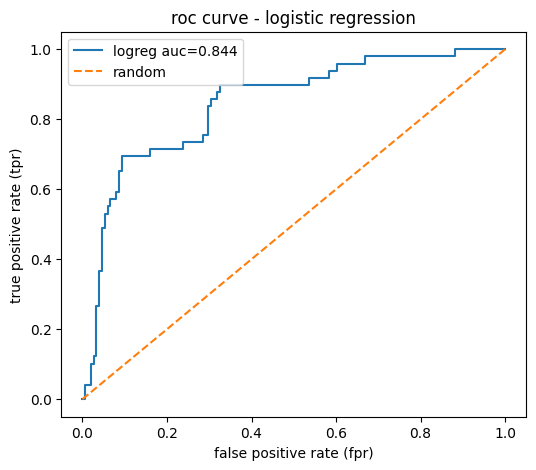

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"logreg auc={auc_lr:.3f}")
plt.plot([0,1], [0,1], linestyle="--", label="random")
plt.xlabel("false positive rate (fpr)")
plt.ylabel("true positive rate (tpr)")
plt.title("roc curve - logistic regression")
plt.legend()
plt.show()

# Model 2: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced_subsample",
        min_samples_leaf=2,
        n_jobs=-1
    ))
])

In [ ]:
rf.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['months_as_customer', 'age', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'capital-gains',
       'capital-loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injur...
       'insured_occupation', 'insured_hobbies', 'insured_relationship',
       'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'property_damage', 'police_report_available', 'auto_make',
       'auto_model'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        min_samples_leaf=2, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

In [ ]:
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

print("random forest")
print("accuracy:", accuracy_score(y_test, pred_rf))
print("precision:", precision_score(y_test, pred_rf, zero_division=0))
print("recall:", recall_score(y_test, pred_rf, zero_division=0))
print("f1:", f1_score(y_test, pred_rf, zero_division=0))
print("roc-auc:", roc_auc_score(y_test, proba_rf))
print("confusion matrix:\n", confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf, zero_division=0))

random forest
accuracy: 0.82
precision: 0.6511627906976745
recall: 0.5714285714285714
f1: 0.6086956521739131
roc-auc: 0.8710636572509798
confusion matrix:
 [[136  15]
 [ 21  28]]
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       151
           1       0.65      0.57      0.61        49

    accuracy                           0.82       200
   macro avg       0.76      0.74      0.75       200
weighted avg       0.81      0.82      0.82       200



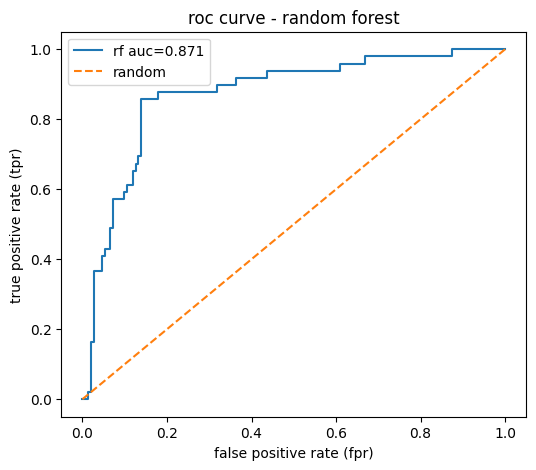

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"rf auc={auc_rf:.3f}")
plt.plot([0,1], [0,1], linestyle="--", label="random")
plt.xlabel("false positive rate (fpr)")
plt.ylabel("true positive rate (tpr)")
plt.title("roc curve - random forest")
plt.legend()
plt.show()

# Model 3: SVC

In [ ]:
from sklearn.svm import SVC

In [ ]:
svc = Pipeline(steps=[
    ("prep", preprocess),
    ("model", SVC(probability=True, class_weight="balanced", random_state=42))
])

In [ ]:
svc.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['months_as_customer', 'age', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'capital-gains',
       'capital-loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injur...
                                                  Index(['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'insured_relationship',
       'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'property_damage', 'police_report_available', 'auto_make',
       'auto_model'],
      dtype='object'))])),
                ('model',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

In [ ]:
pred_svc = svc.predict(X_test)
proba_svc = svc.predict_proba(X_test)[:, 1]

print("svc")
print("accuracy:", accuracy_score(y_test, pred_svc))
print("precision:", precision_score(y_test, pred_svc, zero_division=0))
print("recall:", recall_score(y_test, pred_svc, zero_division=0))
print("f1:", f1_score(y_test, pred_svc, zero_division=0))
print("roc-auc:", roc_auc_score(y_test, proba_svc))
print("confusion matrix:\n", confusion_matrix(y_test, pred_svc))
print(classification_report(y_test, pred_svc, zero_division=0))

svc
accuracy: 0.82
precision: 0.6226415094339622
recall: 0.673469387755102
f1: 0.6470588235294118
roc-auc: 0.8724151912420597
confusion matrix:
 [[131  20]
 [ 16  33]]
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       151
           1       0.62      0.67      0.65        49

    accuracy                           0.82       200
   macro avg       0.76      0.77      0.76       200
weighted avg       0.83      0.82      0.82       200



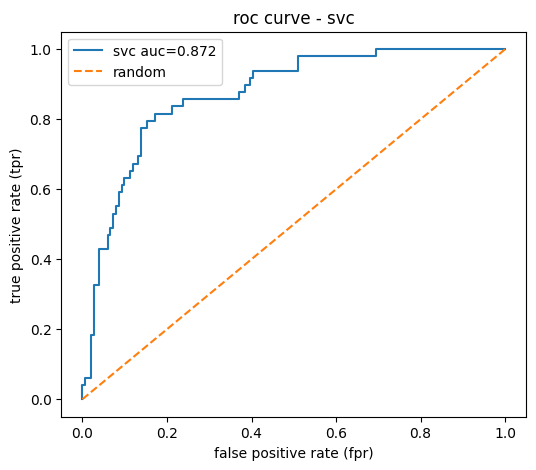

In [ ]:
fpr_svc, tpr_svc, _ = roc_curve(y_test, proba_svc)
auc_svc = auc(fpr_svc, tpr_svc)

plt.figure(figsize=(6,5))
plt.plot(fpr_svc, tpr_svc, label=f"svc auc={auc_svc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", label="random")
plt.xlabel("false positive rate (fpr)")
plt.ylabel("true positive rate (tpr)")
plt.title("roc curve - svc")
plt.legend()
plt.show()

# Ensemble 1: Soft Voting

In [ ]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[("logreg", logreg), ("rf", rf), ("svc", svc)],
    voting="soft"
)

voting.fit(X_train, y_train)

pred_vote = voting.predict(X_test)
proba_vote = voting.predict_proba(X_test)[:, 1]

print("soft voting")
print("accuracy:", accuracy_score(y_test, pred_vote))
print("precision:", precision_score(y_test, pred_vote, zero_division=0))
print("recall:", recall_score(y_test, pred_vote, zero_division=0))
print("f1:", f1_score(y_test, pred_vote, zero_division=0))
print("roc-auc:", roc_auc_score(y_test, proba_vote))
print("confusion matrix:\n", confusion_matrix(y_test, pred_vote))

soft voting
accuracy: 0.845
precision: 0.6956521739130435
recall: 0.6530612244897959
f1: 0.6736842105263158
roc-auc: 0.8737667252331396
confusion matrix:
 [[137  14]
 [ 17  32]]


# Ensemble 2: Stacking

In [ ]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[("logreg", logreg), ("rf", rf), ("svc", svc)],
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    stack_method="predict_proba",
    n_jobs=-1
)

stack.fit(X_train, y_train)

pred_stack = stack.predict(X_test)
proba_stack = stack.predict_proba(X_test)[:, 1]

print("stacking")
print("accuracy:", accuracy_score(y_test, pred_stack))
print("precision:", precision_score(y_test, pred_stack, zero_division=0))
print("recall:", recall_score(y_test, pred_stack, zero_division=0))
print("f1:", f1_score(y_test, pred_stack, zero_division=0))
print("roc-auc:", roc_auc_score(y_test, proba_stack))
print("confusion matrix:\n", confusion_matrix(y_test, pred_stack))

stacking
accuracy: 0.845
precision: 0.6551724137931034
recall: 0.7755102040816326
f1: 0.7102803738317757
roc-auc: 0.8670090552777402
confusion matrix:
 [[131  20]
 [ 11  38]]


# Split train into train/validation for threshold tuning

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [ ]:
models = {"lr": logreg, "rf": rf, "svc": svc, "voting": voting, "stacking": stack}

# Threshold selection function

In [ ]:
def pick_best_threshold(model, X_val, y_val, metric="f1"):
    proba = model.predict_proba(X_val)[:, 1]
    thresholds = np.arange(0.10, 0.91, 0.05)

    best = None
    for t in thresholds:
        pred = (proba >= t).astype(int)
        a = accuracy_score(y_val, pred)
        p = precision_score(y_val, pred, zero_division=0)
        r = recall_score(y_val, pred, zero_division=0)
        f = f1_score(y_val, pred, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()

        row = {"threshold": t, "accuracy" : a, "precision": p, "recall": r, "f1": f,
               "tp": tp, "fp": fp, "tn": tn, "fn": fn}

        score = row[metric]
        if best is None or score > best["score"]:
            best = {"score": score, **row}

    return best

# Evaluate all models (choose threshold on validation → report results on test)

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_tr, y_tr)

    best = pick_best_threshold(model, X_val, y_val, metric="f1")

    test_proba = model.predict_proba(X_test)[:, 1]
    test_pred  = (test_proba >= best["threshold"]).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
    a = accuracy_score(y_test, test_pred)
    p = precision_score(y_test, test_pred, zero_division=0)
    r = recall_score(y_test, test_pred, zero_division=0)
    f = f1_score(y_test, test_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, test_proba)

    results.append({
        "model": name,
        "chosen_threshold": best["threshold"],
        "accuracy" : a,
        "precision": p,
        "recall": r,
        "f1": f,
        "roc_auc": roc_auc,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn
    })

df = pd.DataFrame(results).sort_values("f1", ascending=False)
df

,model,chosen_threshold,accuracy,precision,recall,f1,roc_auc,tp,fp,tn,fn
1,rf,0.30,0.850,0.646154,0.857143,0.736842,0.855926,42,23,128,7
3,voting,0.40,0.850,0.661017,0.795918,0.722222,0.875389,39,20,131,10
4,stacking,0.50,0.835,0.633333,0.775510,0.697248,0.859440,38,22,129,11
0,lr,0.35,0.800,0.567164,0.775510,0.655172,0.841871,38,29,122,11
2,svc,0.35,0.815,0.607143,0.693878,0.647619,0.872753,34,22,129,15
